## 🔊 GUESS THE SOUND 🔊

In [1]:
from datetime import datetime
from __future__ import print_function, division                     # Ensures Python3 printing & division standard
from IPython.display import display, HTML, clear_output
import librosa                                                      #For audio processing    
import math                
import matplotlib.pyplot as plt                                     #For creating plots 
import numpy as np                                                  #For numerical operations
import os                                                           #For interacting with the operating system
import pandas as pd                                                 #For data manipulation and analysis 
from pathlib import Path
import random
import scipy.io.wavfile as wav
from sklearn.preprocessing import LabelEncoder
import sounddevice as sd
import torch
import torchaudio
import torchaudio.transforms as T        
import torch.nn as nn   
from tqdm import tqdm
import time

np.random.seed(42)
random.seed(42)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [2]:
# MULTI-LABEL CLASSIFICATION SETUP

# Spectrogram
CLIP_TIME_M   = 5.94
SAMPLE_RATE_M = 22050
SAMPLE_COUNT_M = int(SAMPLE_RATE_M * CLIP_TIME_M)
HOP_LENGTH_M  = 256
MEL_N_M       = 128
FFT_N_M       = 1024
F_MIN_M       = 100
F_MAX_M       = 10000
DB_MAX_M      = 80.0
FRAME_COUNT_M = math.ceil(SAMPLE_COUNT_M / HOP_LENGTH_M)
NORM_MEAN_M   = -22.69
NORM_STD_M    = 21.58

mel_transform_m = T.MelSpectrogram(
    sample_rate=SAMPLE_RATE_M, n_fft=FFT_N_M, hop_length=HOP_LENGTH_M,
    n_mels=MEL_N_M, f_min=F_MIN_M, f_max=F_MAX_M, power=2.0
)
to_db_m = T.AmplitudeToDB(stype='power', top_db=DB_MAX_M)
 
def audio_to_log_mel_Multi(path, norm_mean=NORM_MEAN_M, norm_std=NORM_STD_M):
    """Produces (1, 128, 512) tensor — matches multi-label training shape."""
    waveform, sr = torchaudio.load(path)
    waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE_M)
    waveform = waveform.mean(dim=0, keepdim=True)
    waveform = waveform.repeat(1, math.ceil(SAMPLE_COUNT_M / waveform.shape[1]))
    mid = (waveform.shape[1] - SAMPLE_COUNT_M) // 2
    waveform = waveform[:, mid : mid + SAMPLE_COUNT_M]
    log_mel = to_db_m(mel_transform_m(waveform))
    if log_mel.shape[-1] < FRAME_COUNT_M:
        log_mel = torch.nn.functional.pad(log_mel, (0, FRAME_COUNT_M - log_mel.shape[-1]))
    else:
        log_mel = log_mel[:, :, :FRAME_COUNT_M]
    return (log_mel - norm_mean) / (norm_std + 1e-6)   # shape: (1, 128, 512)


# Model architecture 
class AudioCNN_Multi(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256),         nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

# Load model and vocab
Multi_MODEL_PATH = "CNN_multi_label.pt"
NUM_CLASSES_Multi = 199
model_Multi = AudioCNN_Multi(num_classes=NUM_CLASSES_Multi).to(device)
model_Multi.load_state_dict(torch.load(Multi_MODEL_PATH, map_location=device, weights_only=False))
model_Multi.eval()
vocab = pd.read_csv("vocabulary.csv")
vocab.columns = ["index", "label", "mid"]
idx_to_label = dict(zip(vocab["index"], vocab["label"]))

In [3]:
# MULTI-LABEL CLASSIFICATION SETUP 2

# Spectrogram
SAMPLE_RATE = 22050
N_MELS      = 128
HOP_LENGTH  = 256
N_FFT       = 1024
F_MIN       = 100
F_MAX       = 10000             
FRAME_COUNT = 512  # must match model 2's training shape

mel_transform = T.MelSpectrogram(
    sample_rate = SAMPLE_RATE,
    n_fft       = N_FFT,
    hop_length  = HOP_LENGTH,
    n_mels      = N_MELS,
    f_min       = F_MIN,
    f_max       = F_MAX,
    power       = 2.0,
)
to_db = T.AmplitudeToDB(stype="power", top_db=80.0)

def process_audio(path: Path) -> torch.Tensor:
    """Load a .wav and return an unnormalized log-mel spectrogram."""
    waveform, sr = torchaudio.load(path)
    waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)
    waveform = waveform.mean(dim=0, keepdim=True)   # stereo → mono
    return to_db(mel_transform(waveform))            # (1, 128, time_frames)


# Model architecture 
class AudioCNN_Multi_version2(nn.Module):
    """Four convolutional blocks followed by global average pooling
    and a linear classifier.
    Each block:
        Conv2d → BatchNorm → ReLU → MaxPool """
    def __init__(self, num_classes: int = 200):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1 — learns low-level features (edges in freq/time) 
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),              

            # Block 2 — learns mid-level patterns (harmonics, rhythms)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3 — learns higher-level combinations 
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4 — learns abstract sound representations 
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),)

        # features: 3 blocks with MaxPool, then AdaptiveAvgPool
        self.gap = nn.AdaptiveAvgPool2d((4, 4))  # → (batch, 128, 4, 4)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(128 * 4 * 4, 512), nn.ReLU(),
                                      nn.Dropout(0.3), nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.2),
                                      nn.Linear(256, num_classes))

    def forward(self, x):
        x = self.features(x)  
        x = self.gap(x)       
        x = x.flatten(1)        
        x = self.classifier(x) 
        return x


# Load model and vocab
Multi_MODEL_PATH_2 = "full_model_13.pt"
NUM_CLASSES_Multi_2 = 200
model_Multi_2 = AudioCNN_Multi_version2(num_classes=NUM_CLASSES_Multi_2).to(device)
model_Multi_2.load_state_dict(torch.load(Multi_MODEL_PATH_2, map_location=device, weights_only=False))
model_Multi_2.eval()
vocab_2 = pd.read_csv("vocabulary.csv", header=None, names=["index", "label", "mid"])
idx_to_label_2 = dict(zip(vocab_2["index"], vocab_2["label"]))
NORM_MEAN_2 = -21.5820
NORM_STD_2  = 20.2802

In [4]:
# SINGLE-LABEL CLASSIFICATION SETUP

# Spectrogram 
def extract_spectrogram_6fam(filepath):
    DURATION_6fam = 5.0      # hardcoded — independent of any global DURATION
    N_MELS_6fam   = 64
    HOP_6fam      = 512
    N_FRAMES_6fam = int(22050 * DURATION_6fam / HOP_6fam) + 1  # = 216
    try:
        audio, sr = librosa.load(filepath, sr=22050, mono=True)  # no duration= here!
        expected_samples = int(22050 * DURATION_6fam)
        if len(audio) < expected_samples:
            repeats = -(-expected_samples // len(audio))
            audio = np.tile(audio, repeats)[:expected_samples]
        else:
            audio = audio[:expected_samples]  # trim to exactly 5.0s
        mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=N_MELS_6fam, hop_length=HOP_6fam)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        return mel_db[:, :N_FRAMES_6fam]  # shape: (64, 216)
    except:
        return None


# Model architecture 
class AudioCNN_Optuna(nn.Module):
    def __init__(self, n_classes, dropout):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.LazyLinear(256),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Dropout(dropout),  # second dropout
        nn.Linear(128, n_classes)
    )
    def forward(self, x):
        return self.classifier(self.conv(x))

# Load model and corresponding stats 
mean, std, dropout = np.load(f"train_stats.npy")
le = LabelEncoder()
le.classes_ = np.load(f"label_encoder_classes.npy", allow_pickle=True)
n_classes = len(le.classes_)
SINGLE_MODEL_PATH = f"single_model_fp16.pth" 
model_single = AudioCNN_Optuna(n_classes, dropout=dropout).to(device)
model_single.load_state_dict(torch.load(SINGLE_MODEL_PATH, map_location=device, weights_only=False))
model_single = model_single.float().to(device) 
model_single.eval()
get_pranked = True

Recording in 3...
Recording in 2...
Recording in 1...


🎙 Recording! |█████████▉| 6.0/6.0s


✅ Done! Analyzing...


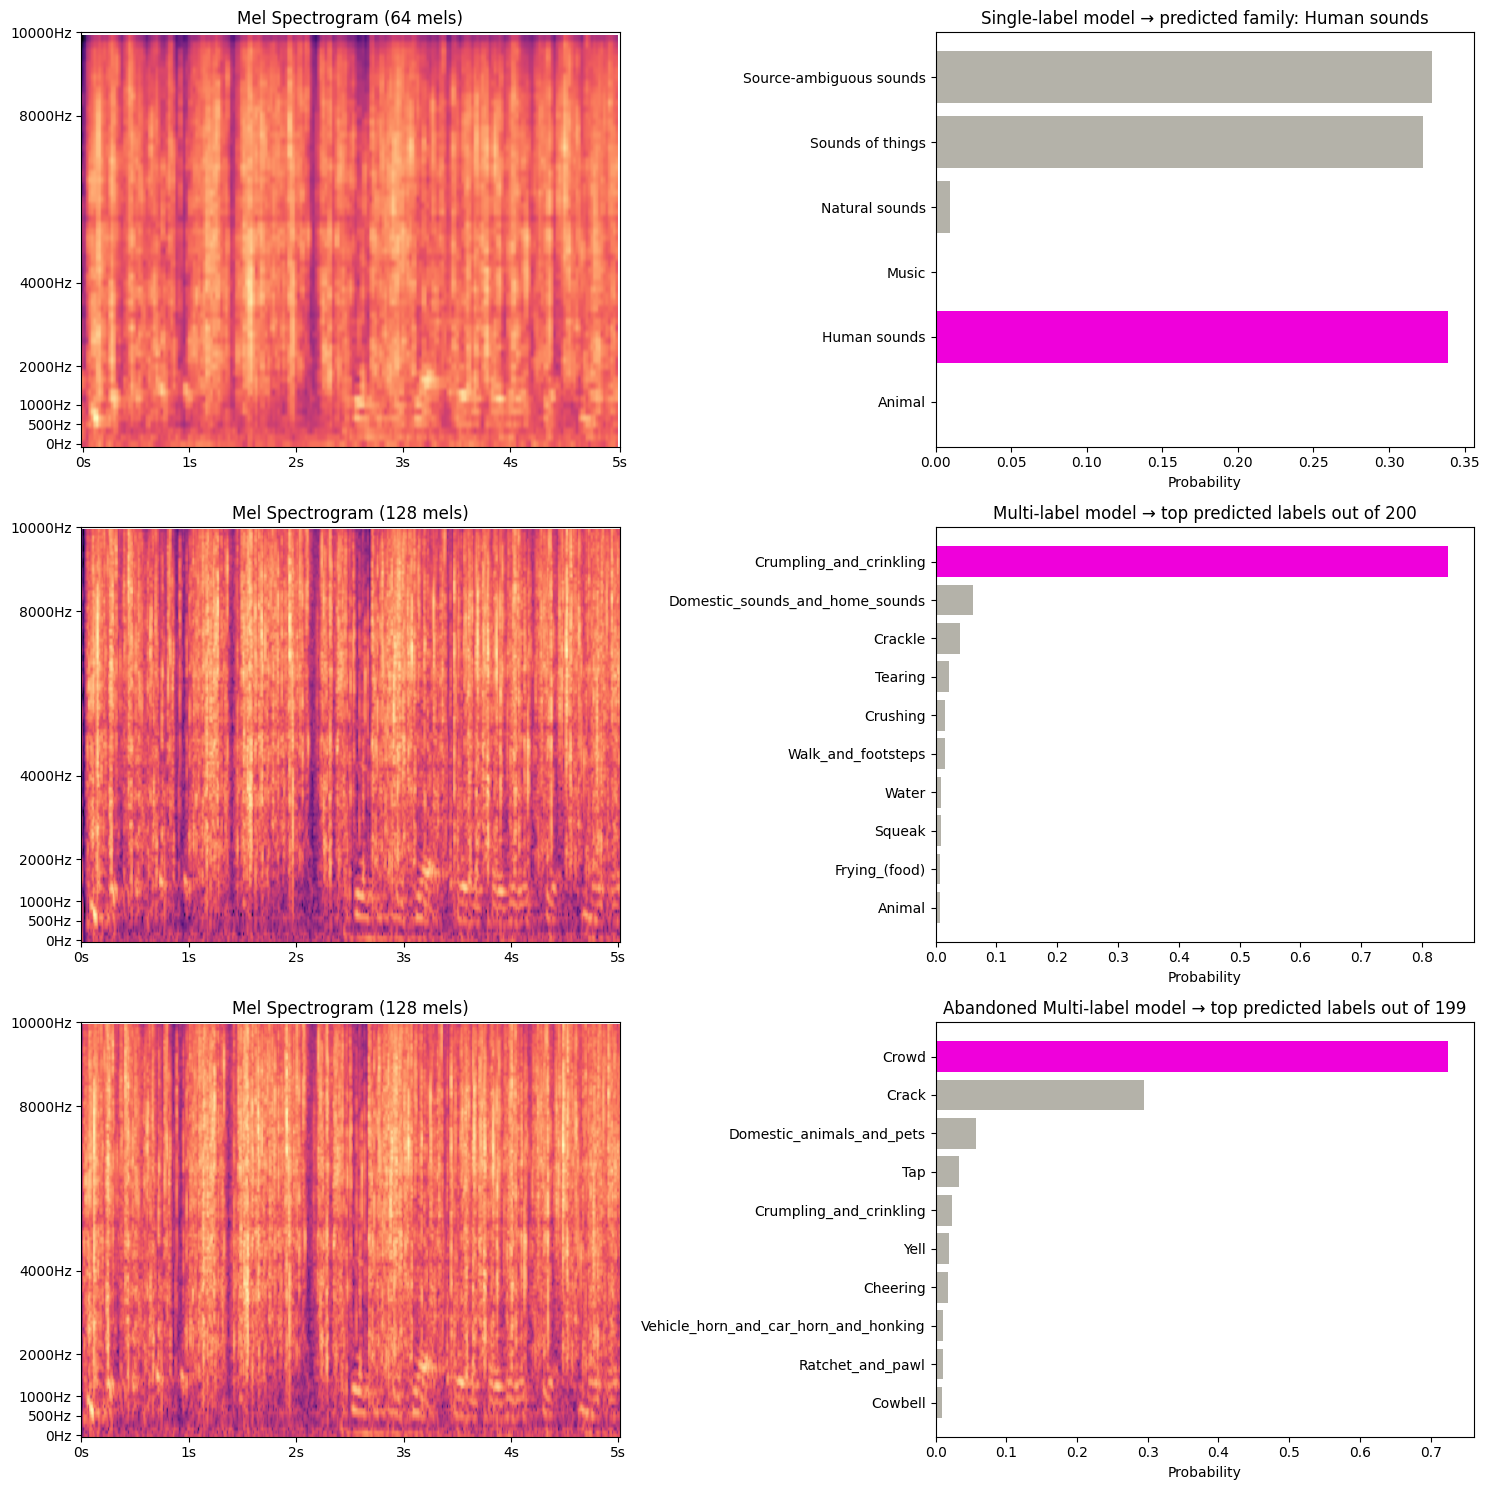

⏱ Total analysis and plotting time: 0.90 seconds


In [28]:
# Things for audio recording, spectrogram extraction and plotting
clear_output(wait=True)

RECORD_DURATION = 6.0  #seconds

freq_ticks = [0, 500, 1000, 2000, 4000, 8000, 10000]  # Hz
time_ticks = [0, 1, 2, 3, 4, 5]  # seconds

emojis = {
    "Human sounds": "🧍🏻",
    "Animal": "🐶",
    "Music": "🎵",
    "Natural sounds": "🌳",
    "Sounds of things": "🔧",
    "Source-ambiguous sounds": "❓"}


# Countdown for recording
print("Recording in 3...")
import time; time.sleep(1)
print("Recording in 2...")
time.sleep(1)
print("Recording in 1...")
time.sleep(1)


#Progress bar for recording
recording = sd.rec(int(RECORD_DURATION * SAMPLE_RATE_M), samplerate=SAMPLE_RATE_M, channels=1)
interval = 0.1  
steps = int(RECORD_DURATION / interval)
with tqdm(total=RECORD_DURATION, desc="🎙 Recording!", bar_format="{desc} |{bar}| {n:.1f}/{total:.1f}s") as pbar:
    for _ in range(steps):
        time.sleep(interval)
        pbar.update(interval)

sd.wait()
print("✅ Done! Analyzing...")

start_time = time.time()

# Save file temporary
save_path = "Recording_{}.wav".format(datetime.now().strftime('%Y-%m-%d_%H:%M'))
wav.write(save_path, SAMPLE_RATE_M, recording)


# Multi-label analysis
spec_Multi = audio_to_log_mel_Multi(save_path)
X_Multi = spec_Multi.unsqueeze(0).to(device)
with torch.no_grad():
    probs_Multi = torch.sigmoid(model_Multi(X_Multi)).cpu().numpy()[0]
top_idx    = probs_Multi.argsort()[::-1][:10]
top_probs  = probs_Multi[top_idx]
top_labels = [idx_to_label[i] for i in top_idx]


#Multi-label analysis 2
spec_Multi_2 = process_audio(save_path)
if spec_Multi_2.shape[-1] < FRAME_COUNT:
    repeats = math.ceil(FRAME_COUNT / spec_Multi_2.shape[-1])
    spec_Multi_2 = spec_Multi_2.repeat(1, 1, repeats)
start = random.randint(0, spec_Multi_2.shape[-1] - FRAME_COUNT)
spec_Multi_2  = spec_Multi_2[:, :, start:start + FRAME_COUNT]
spec_Multi_2 = (spec_Multi_2 - NORM_MEAN_2) / (NORM_STD_2 + 1e-6)
X_Multi_2 = spec_Multi_2.unsqueeze(0).to(device)
with torch.no_grad():
    probs_Multi_2 = torch.sigmoid(model_Multi_2(X_Multi_2)).cpu().numpy()[0]
top_idx_2    = probs_Multi_2.argsort()[::-1][:10]
top_probs_2  = probs_Multi_2[top_idx_2]
top_labels_2 = [idx_to_label_2[i] for i in top_idx_2]


# Single-label analysis
spec_Single = extract_spectrogram_6fam(save_path)
X_Single = np.array([spec_Single])[:, np.newaxis, :, :]
X_Single = (X_Single - mean) / std
X_Single_t = torch.tensor(X_Single, dtype=torch.float32).to(device)
with torch.no_grad():
    probs = torch.softmax(model_single(X_Single_t), dim=1).cpu().numpy()[0]
predicted_class = le.classes_[np.argmax(probs)]

#Show emoji for predicted family
display(HTML(f"<div style='font-size:400px; text-align:center'>{emojis[predicted_class]}</div>"))

#Plotting
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
spec_display = spec_Multi.squeeze().numpy()
spec_display_2 = spec_Multi_2.squeeze()


axes[0, 0].imshow(spec_Single, aspect="auto", origin="lower", cmap="magma") 
axes[0, 0].set_title("Mel Spectrogram (64 mels)")
axes[0, 0].set_yticks([int(b * 64 / 10000) for b in freq_ticks])
axes[0, 0].set_yticklabels([f"{f}Hz" for f in freq_ticks])
axes[0, 0].set_xticks([int(t * 216 / 5.0) for t in time_ticks])
axes[0, 0].set_xticklabels([f"{t}s" for t in time_ticks])

axes[0, 1].barh(le.classes_, probs, color=["#EF00DB" if c == predicted_class else "#B4B2A9" for c in le.classes_])
axes[0, 1].set_xlabel("Probability")
axes[0, 1].set_title(f"Single-label model → predicted family: {predicted_class}")

axes[1, 0].imshow(spec_display_2, aspect="auto", origin="lower", cmap="magma")
axes[1, 0].set_title("Mel Spectrogram (128 mels)")
axes[1, 0].set_yticks([int(b * 128 / 10000) for b in freq_ticks])
axes[1, 0].set_yticklabels([f"{f}Hz" for f in freq_ticks])
axes[1, 0].set_xticks([int(t * 512 / 5.94) for t in time_ticks])
axes[1, 0].set_xticklabels([f"{t}s" for t in time_ticks])
axes[1, 0].set_xlim(0, 431) # 431 = int(5.0 * 512 / 5.94), crops display to 5s to match single-label spectrogram

axes[1, 1].barh(top_labels_2, top_probs_2,  color=["#EF00DB" if l >= 0.5 else "#B4B2A9" for l in top_probs_2])
axes[1, 1].set_xlabel("Probability")
axes[1, 1].set_title("Multi-label model → top predicted labels out of 200")
axes[1, 1].invert_yaxis()

axes[2, 0].imshow(spec_display, aspect="auto", origin="lower", cmap="magma")
axes[2, 0].set_title("Mel Spectrogram (128 mels)")
axes[2, 0].set_yticks([int(b * 128 / 10000) for b in freq_ticks])
axes[2, 0].set_yticklabels([f"{f}Hz" for f in freq_ticks])
axes[2, 0].set_xticks([int(t * 512 / 5.94) for t in time_ticks])
axes[2, 0].set_xticklabels([f"{t}s" for t in time_ticks])
axes[2, 0].set_xlim(0, 431) # 431 = int(5.0 * 512 / 5.94), crops display to 5s to match single-label spectrogram

axes[2, 1].barh(top_labels, top_probs,  color=["#EF00DB" if l >= 0.5 else "#B4B2A9" for l in top_probs])
axes[2, 1].set_xlabel("Probability")
axes[2, 1].set_title("Abandoned Multi-label model → top predicted labels out of 199")
axes[2, 1].invert_yaxis()

plt.tight_layout()
plt.show()


#Print analysis time
end_time = time.time()
print(f"⏱ Total analysis and plotting time: {end_time - start_time:.2f} seconds")

#Remove temporary file
os.remove(save_path)
